#### Smart Logistics & Inventory Engine.

###### Objetivo: Crear un sistema de inteligencia de negocios que prediga la demanda diaria de insumos y optimice las rutas de reparto basandose en la probabilidad de "cuellos de botella" logisticos.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, zscore

#### Simulacion de Datos

In [2]:
rng = np.random.default_rng(7)
dias = 90

# Demanda de Parrillas: Usamos una distribucion Log-Normal
# porque las ventas de comida suelen tener asimetria positiva (dias de pico alto)
demanda_parrillas = rng.lognormal(mean=3.4, sigma=0.4, size=dias).astype(int)

# Tiempos de Entrega (en minutos): Promedio 30 min, con algunos outliers de trafico
tiempos_entrega = rng.normal(loc=30, scale=8, size=dias)
tiempos_entrega[10] = 75  # Anomalia: Accidente en ruta
tiempos_entrega[45] = 90  # Anomalia: Lluvia extrema en Huacho

# Ventas de Complementos (para Matriz de Covarianza)
ventas_gaseosas = demanda_parrillas * 0.8 + rng.normal(0, 5, dias)
ventas_chorizos = demanda_parrillas * 0.5 + rng.normal(0, 3, dias)

df_lion = pd.DataFrame({
    'Dia': np.arange(1, dias + 1),
    'Ventas_Parrilla': demanda_parrillas,
    'Tiempo_Entrega': tiempos_entrega,
    'Ventas_Gaseosa': ventas_gaseosas,
    'Ventas_Chorizo': ventas_chorizos
})

#### Analisis de momentos

In [3]:
def analizar_inventario(data):
    mu = data.mean()
    mediana = data.median()
    sigma = data.std()
    sk = skew(data)
    kur = kurtosis(data)

    # Calculo de Stock de Seguridad Profesional:
    # Si la Skewness es alta, el promedio no basta.
    # Usamos el percentil 95 (CDF) para asegurar que no falte carne.
    stock_seguridad = np.percentile(data, 95)

    print("--- Analisis de Demanda Lion Hungry ---")
    print(f"Valor Esperado (Media): {mu:.2f} unidades/dia")
    print(f"Mediana (Robusta): {mediana:.2f}")
    print(f"Desviacion estandar: {sigma:.2f}")
    print(f"Skewness (Asimetria): {sk:.2f} (Si > 0, hay picos de demanda alta)")
    print(f"Kurtosis: {kur:.2f} (Si es alta, hay dias de demanda extrema)")
    print(f"Stock Recomendado (Percentil 95): {stock_seguridad:.0f} unidades")

analizar_inventario(df_lion['Ventas_Parrilla'])

--- Analisis de Demanda Lion Hungry ---
Valor Esperado (Media): 29.22 unidades/dia
Mediana (Robusta): 27.50
Desviacion estandar: 10.45
Skewness (Asimetria): 0.94 (Si > 0, hay picos de demanda alta)
Kurtosis: 0.98 (Si es alta, hay dias de demanda extrema)
Stock Recomendado (Percentil 95): 50 unidades


#### Control Logistico

In [4]:
# Identificamos quÃ© entregas fueron "AnomalÃ­as" estadÃ­sticas
df_lion['Z_Tiempo'] = zscore(df_lion['Tiempo_Entrega'])
retrasos_criticos = df_lion[df_lion['Z_Tiempo'] > 2.5] # MÃ¡s de 2.5 sigmas

print("\n--- Alerta LogÃ­stica ---")
print(f"DÃ­as con retrasos anÃ³malos detectados: {len(retrasos_criticos)}")
print(retrasos_criticos[['Dia', 'Tiempo_Entrega', 'Z_Tiempo']])


--- Alerta LogÃ­stica ---
DÃ­as con retrasos anÃ³malos detectados: 2
    Dia  Tiempo_Entrega  Z_Tiempo
10   11            75.0  4.259247
45   46            90.0  5.664289


#### Optimizacion / Covarianza

In [5]:
menu_cols = ['Ventas_Parrilla', 'Ventas_Gaseosa', 'Ventas_Chorizo']
matrix_corr = df_lion[menu_cols].corr()

print("\n--- Matriz de CorrelaciÃ³n de MenÃº ---")
print(matrix_corr)


--- Matriz de CorrelaciÃ³n de MenÃº ---
                 Ventas_Parrilla  Ventas_Gaseosa  Ventas_Chorizo
Ventas_Parrilla         1.000000        0.851781        0.868478
Ventas_Gaseosa          0.851781        1.000000        0.765926
Ventas_Chorizo          0.868478        0.765926        1.000000


#### Visualizacion

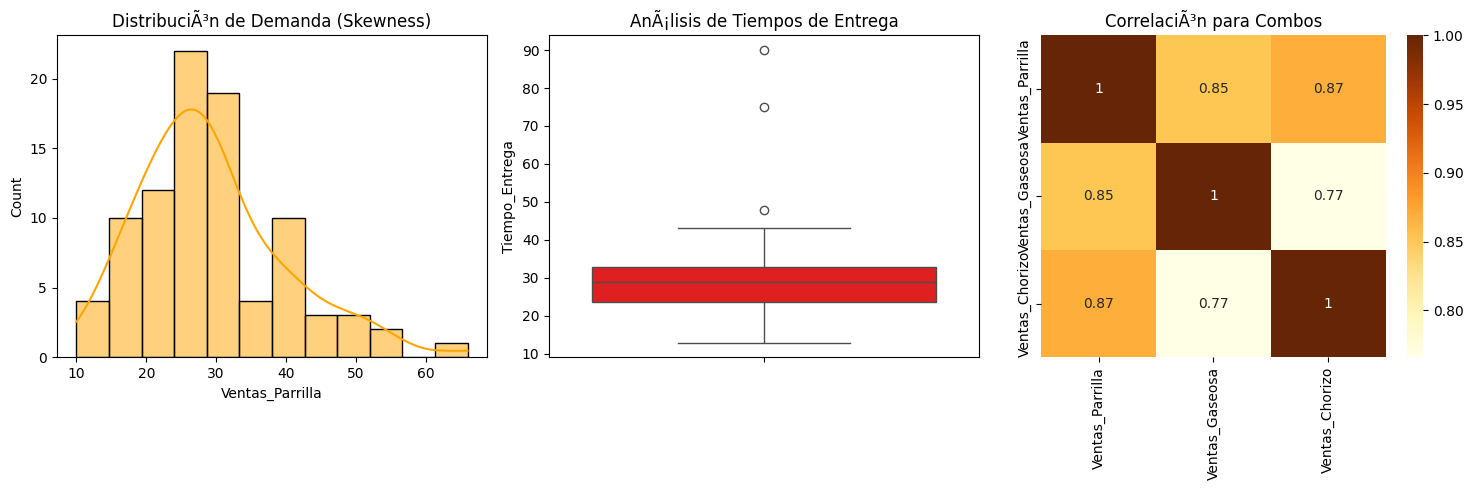

In [6]:
plt.figure(figsize=(15, 5))

# Plot 1: DistribuciÃ³n de Ventas (Skewness)
plt.subplot(1, 3, 1)
sns.histplot(df_lion['Ventas_Parrilla'], kde=True, color='orange')
plt.title('DistribuciÃ³n de Demanda (Skewness)')

# Plot 2: Box-Plot de Tiempos (Outliers)
plt.subplot(1, 3, 2)
sns.boxplot(y=df_lion['Tiempo_Entrega'], color='red')
plt.title('AnÃ¡lisis de Tiempos de Entrega')

# Plot 3: Heatmap de CorrelaciÃ³n
plt.subplot(1, 3, 3)
sns.heatmap(matrix_corr, annot=True, cmap='YlOrBr')
plt.title('CorrelaciÃ³n para Combos')

plt.tight_layout()
plt.show()